#PROJECT-TITLE

**Amazon Product Analysis: Pricing, Discounts, Ratings, and Customer Reviews**

PROBLEM-STATEMENT

Amazon offers thousands of products across multiple categories with varying prices, discounts, ratings, and customer reviews. Understanding customer preferences and product performance is essential for improving sales strategies and customer satisfaction.


The objective of this project is to analyze Amazon product data to identify trends in pricing, discounts, ratings, and customer reviews. The analysis aims to uncover factors that influence product popularity, evaluate the effectiveness of discount strategies, compare product categories, and generate actionable insights that can help businesses optimize pricing, improve customer experience, and enhance product performance.

In [ ]:
#importing req libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/amazon.csv")

**Objectives**
Analyze the distribution of product prices, discounts, and ratings.

Identify the most popular and highest-rated product categories.

Examine the relationship between discounts and customer ratings.

Determine which products receive the highest customer engagement.

Compare actual prices with discounted prices across categories.

Discover patterns in customer reviews and ratings.

Generate business insights and recommendations for improving sales and customer satisfaction.

#Data Understanding

In [ ]:
df.shape

(1465, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

1465 products are present in data set.

16 columns are presesnted in data set.

#DATA CLEANING

In [ ]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [ ]:
#deleting unwanted columns
df=df.drop(columns=["rating_count","about_product","user_name","review_id","review_title","review_content","img_link","product_link"],errors="coerce")


In [ ]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'user_id'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
user_id,0


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1460,False
1461,False
1462,False
1463,False


In [ ]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,user_id
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB..."
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX..."
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ..."
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S..."
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH..."


No null values in dats set.

no duplicated values in data set.

currently prices contains rupess symbol and commas we have to covert it.

In [ ]:
df['discounted_price'] = df['discounted_price'].str.replace('₹','')
df['discounted_price'] = df['discounted_price'].str.replace (',','')
df['discounted_price'] = pd.to_numeric(df['discounted_price'])

df['actual_price'] = df['actual_price'].str.replace('₹','')
df['actual_price'] = df['actual_price'].str.replace(',','')
df['actual_price'] = pd.to_numeric(df['actual_price'])

discounts coluymns also contain some symbols which are realted to object data type.

In [ ]:
df["discount_percentage"]=df["discount_percentage"].str.replace("%","")
df["discount_percentage"]=pd.to_numeric(df["discount_percentage"])

rating column also presented in object data type.we have to convert it into numeric

In [ ]:
df["rating"]=df["rating"].str.replace("|","")
df["rating"]=pd.to_numeric(df["rating"])

In [ ]:
df.to_csv("amazon_cleaned.csv")

#Feature Engineering

In [ ]:
df['main_category'] = df['category'].str.split('|').str[0]

In [ ]:
df['savings'] = df['actual_price'] - df['discounted_price']

  1.How many products and features are present in the dataset?

In [ ]:
df["main_category"].value_counts().sum()

np.int64(1465)

In [ ]:
df.shape

(1465, 10)

totally 1465 products and 10 featues like product_id,produt_name,cateogry,dis_price,rating etc... presesnted in the data set.

 2.

#Product & Category Analysis

 1.Which product category contains the highest number of products?

In [ ]:
df["main_category"].value_counts()

,count
main_category,
Electronics,526
Computers&Accessories,453
Home&Kitchen,448
OfficeProducts,31
MusicalInstruments,2
HomeImprovement,2
Toys&Games,1
Car&Motorbike,1
Health&PersonalCare,1


electronics category have high number of products overall.

 2.Which categories have the highest and lowest average product ratings?

In [ ]:
df.groupby("main_category").agg({"rating":"mean"}).sort_values(by="rating",ascending=False)

,rating
main_category,
OfficeProducts,4.309677
Toys&Games,4.300000
HomeImprovement,4.250000
Computers&Accessories,4.154967
Electronics,4.081749
Home&Kitchen,4.040716
Health&PersonalCare,4.000000
MusicalInstruments,3.900000
Car&Motorbike,3.800000


OfficeProducts product has highest average rating &

 Car&Motorbike produts has lowest average rating

 3.Which categories offer the highest average discount percentages?

In [ ]:
df.groupby("main_category").agg({"discount_percentage":"mean"}).sort_values(by="discount_percentage",ascending=False)

,discount_percentage
main_category,
HomeImprovement,57.500000
Computers&Accessories,54.024283
Health&PersonalCare,53.000000
Electronics,50.828897
MusicalInstruments,46.000000
Car&Motorbike,42.000000
Home&Kitchen,40.120536
OfficeProducts,12.354839
Toys&Games,0.000000


HomeImprovement category offers highest average discount percentages

 # Pricing Analysis

 1.What is the distribution of actual prices and discounted prices?

In [ ]:
df["actual_price"].min()

39.0

In [ ]:
df["actual_price"].max()

139900.0

In [ ]:
df["actual_price"].median()

1650.0

In [ ]:
df["discounted_price"].describe()

,discounted_price
count,1465.000000
mean,3125.310874
std,6944.304394
min,39.000000
25%,325.000000
50%,799.000000
75%,1999.000000
max,77990.000000


The actual prices range from ₹39 to ₹139,900, with an average price of approximately ₹5,445. The discounted prices range from ₹39 to ₹77,990, with an average price of approximately ₹3,125. The median actual price (₹1,650) is much lower than the mean, indicating that a few high-priced products increase the average. Similarly, the median discounted price is ₹799, showing that most products are sold at relatively affordable prices after discounts.

 2.Which products provide the highest savings to customers

In [ ]:
df.groupby("product_name").agg({"savings":"sum"}).sort_values(by="savings",ascending=False)

,savings
product_name,
"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Watch with Bluetooth Calling, AI Voice Assistance, 100 Sports Modes IP67 Rating, 240*280 Pixel High Resolution",91000.0
Sony Bravia 164 cm (65 inches) 4K Ultra HD Smart LED Google TV KD-65X74K (Black),61910.0
"Coway Professional Air Purifier for Home, Longest Filter Life 8500 Hrs, Green True HEPA Filter, Traps 99.99% Virus & PM 0.1 Particles, Warranty 7 Years (AirMega 150 (AP-1019C))",45500.0
"Fire-Boltt Visionary 1.78"" AMOLED Bluetooth Calling Smartwatch with 368*448 Pixel Resolution 100+ Sports Mode, TWS Connection, Voice Assistance, SPO2 & Heart Rate Monitoring",40000.0
"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM, 128GB Storage) with No Cost EMI & Additional Exchange Offers",37009.0
...,...
"Samsung Original Type C to C Cable - 3.28 Feet (1 Meter), White",0.0
"OnePlus Nord 2T 5G (Gray Shadow, 8GB RAM, 128GB Storage)",0.0
"OnePlus Nord 2T 5G (Jade Fog, 12GB RAM, 256GB Storage)",0.0


THESE ARE THE PRODUCTS THAT PROVIDE HIGH SAVINGS

 Fire-Boltt Ninja Call Pro Plus 1.83" Smart Watch with Bluetooth Calling, AI Voice Assistance, 100 Sports Modes IP67 Rating, 240*280 Pixel High Resolution	**91000.0**

Sony Bravia 164 cm (65 inches) 4K Ultra HD Smart LED Google TV KD-65X74K (Black)	**61910.0**

Coway Professional Air Purifier for Home, Longest Filter Life 8500 Hrs, Green True HEPA Filter, Traps 99.99% Virus & PM 0.1 Particles, Warranty 7 Years (AirMega 150 (AP-1019C))	**45500.0**

Fire-Boltt Visionary 1.78" AMOLED Bluetooth Calling Smartwatch with 368*448 Pixel Resolution 100+ Sports Mode, TWS Connection, Voice Assistance, SPO2 & Heart Rate Monitoring	**40000.0**

Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM, 128GB Storage) with No Cost EMI & Additional Exchange Offers	**37009.0**

 3.Are expensive products generally rated higher than cheaper products?

In [ ]:
df[['actual_price', 'rating']].corr()

,actual_price,rating
actual_price,1.000000,0.121642
rating,0.121642,1.000000


Correlation close to +1 → expensive products tend to have higher ratings

# Ratings & Reviews Analysis

1.Which products have the highest number of ratings (most popular products)?

In [ ]:
df.nlargest(10, 'rating')[['product_name', 'rating']]

,product_name,rating
174,Syncwire LTG to USB Cable for Fast Charging Co...,5.0
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",5.0
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,5.0
1145,Swiffer Instant Electric Water Heater Faucet T...,4.8
1201,"Oratech Coffee Frother electric, milk frother ...",4.8
1299,"Instant Pot Air Fryer, Vortex 2QT, Touch Contr...",4.8
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,4.7
459,Spigen EZ Fit Tempered Glass Screen Protector ...,4.7
1223,"FIGMENT Handheld Milk Frother Rechargeable, 3-...",4.7
1226,Zuvexa USB Rechargeable Electric Foam Maker - ...,4.7


In [ ]:
df[['product_name', 'rating']].sort_values(
    by='rating',
    ascending=False
).head(5)

,product_name,rating
174,Syncwire LTG to USB Cable for Fast Charging Co...,5.0
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",5.0
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,5.0
1299,"Instant Pot Air Fryer, Vortex 2QT, Touch Contr...",4.8
1201,"Oratech Coffee Frother electric, milk frother ...",4.8


THESE ARE THE PRODUCTS HAVE HIGHEST RATING

174	Syncwire LTG to USB Cable for Fast Charging Co...	5.0

324	REDTECH USB-C to Lightning Cable 3.3FT, Apple...	5.0

775	Amazon Basics Wireless Mouse | 2.4 GHz Connect...	5.0

1299	Instant Pot Air Fryer, Vortex 2QT, Touch Contr...	4.8

1201	Oratech Coffee Frother electric, milk frother ...	4.8

 2.Do products with higher discounts receive better ratings

In [ ]:
df.pivot_table(index="product_name",values=["discounted_price","rating"],aggfunc="mean")

,discounted_price,rating
product_name,,
!!1000 Watt/2000-Watt Room Heater!! Fan Heater!!Pure White!!HN-2500!!Made in India!!,784.0,4.5
!!HANEUL!!1000 Watt/2000-Watt Room Heater!! Fan Heater!!Pure White!!HN-2500!!Made in India!!Thermoset!!,899.0,3.4
"10WeRun Id-116 Bluetooth Smartwatch Wireless Fitness Band for Boys, Girls, Men, Women & Kids | Sports Gym Watch for All Smart Phones I Heart Rate and spo2 Monitor",499.0,4.1
"10k 8k 4k HDMI Cable, Certified 48Gbps 1ms Ultra High Speed HDMI 2.1 Cable 4k 120Hz 144Hz 2k 165Hz 8k 60Hz Dynamic HDR ARC eARC DTS:X Compatible for Mac Gaming PC Soundbar TV Monitor Laptop PS5 4 Xbox",999.0,4.6
"3M Post-it Sticky Note Cube, 200 Sheets (4 Colors x 50 Sheets) | 3"" x 3"" Size | For notes, reminders, study, school and organizing",90.0,4.4
...,...,...
"realme Buds Wireless in Ear Bluetooth Earphones with mic, 11.2mm Bass Boost Driver, Magnetic Fast Pair, Fast Charging and 12 Hrs Playtime (Yellow)",1679.0,4.1
"realme narzo 50 (Speed Blue, 4GB RAM+64GB Storage) Helio G96 Processor | 50MP AI Triple Camera | 120Hz Ultra Smooth Display",12999.0,4.2
"realme narzo 50i (Mint Green, 2GB RAM+32GB Storage) Octa Core Processor | 6.5"" inch Large Display",7499.0,4.0


not all discounted products have highest rating.there is no linear relationship.

# Business Insights

 1.Which category provides the best value for money (high rating + high discount)?

In [ ]:
df.pivot_table(index="main_category",values=["rating","discounted_price"],aggfunc="mean").sort_values(by="rating",ascending=False)

,discounted_price,rating
main_category,,
OfficeProducts,301.580645,4.309677
Toys&Games,150.000000,4.300000
HomeImprovement,337.000000,4.250000
Computers&Accessories,842.650375,4.154967
Electronics,5965.887833,4.081749
Home&Kitchen,2330.615647,4.040716
Health&PersonalCare,899.000000,4.000000
MusicalInstruments,638.000000,3.900000
Car&Motorbike,2339.000000,3.800000


OfficeProducts had provided  (high rating + high discount).

2.What factors appear to influence product ratings the most?

In [ ]:
df[['actual_price','rating']].corr()

,actual_price,rating
actual_price,1.000000,0.121642
rating,0.121642,1.000000


More expensive products tend to receive slightly higher ratings

#Visualizations

**1. Category Distribution**

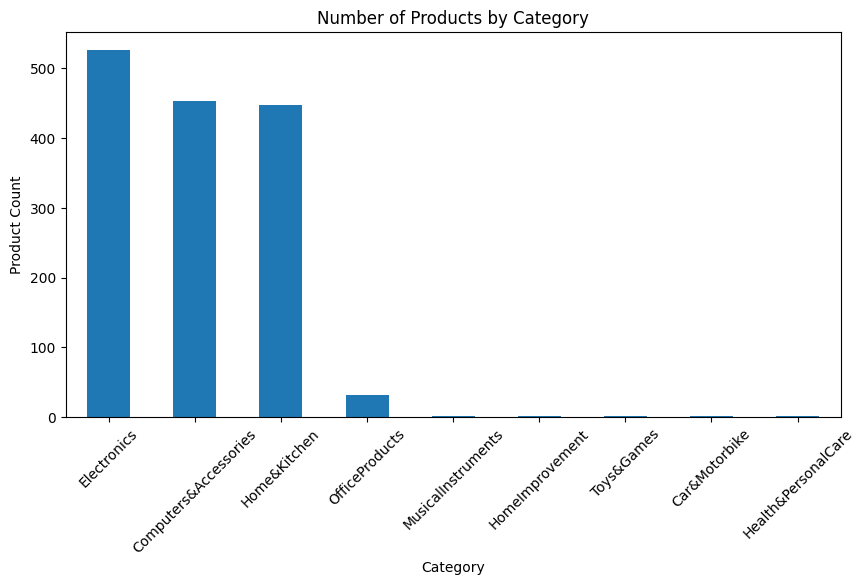

In [ ]:
df['main_category'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Number of Products by Category')
plt.xlabel('Category')
plt.ylabel('Product Count')
plt.xticks(rotation=45)
plt.show()

2.. **Rating Distribution**

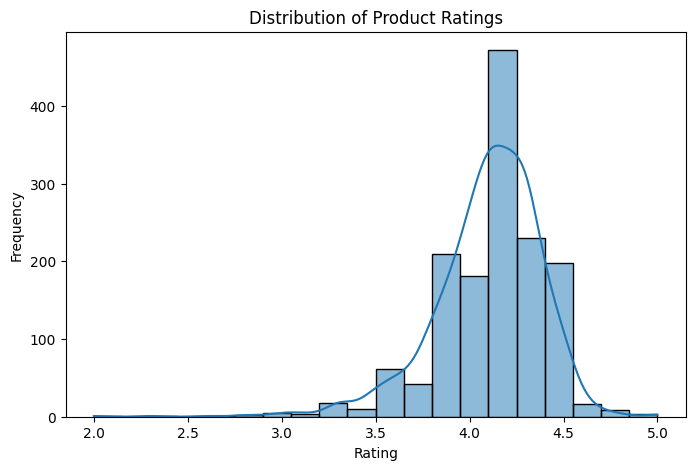

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['rating'], bins=20, kde=True)

plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

3.**Actual Price vs Discounted Price**

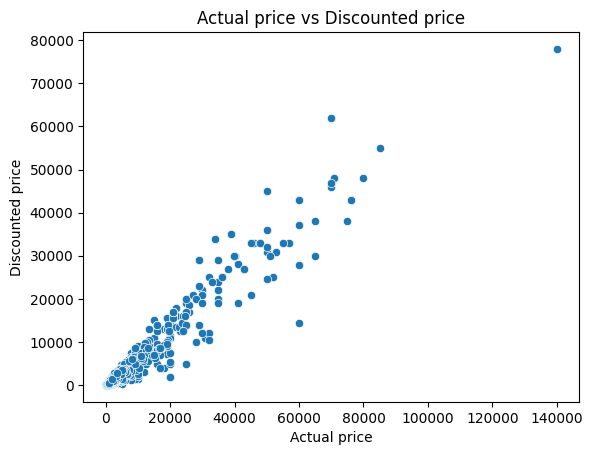

In [ ]:
sns.scatterplot(data=df,x="actual_price",y="discounted_price")
plt.title("Actual price vs Discounted price")
plt.xlabel("Actual price")
plt.ylabel("Discounted price")
plt.show()

 4.**Average Rating by Category**

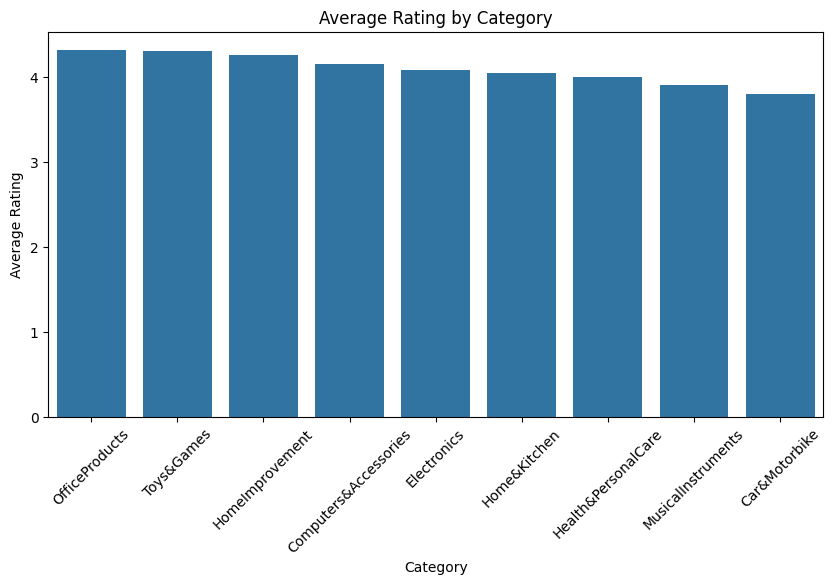

In [ ]:
avg_rating = df.groupby('main_category')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x=avg_rating.index,
    y=avg_rating.values
)

plt.xticks(rotation=45)
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.title("Average Rating by Category")
plt.show()

5. Average Discount by Category

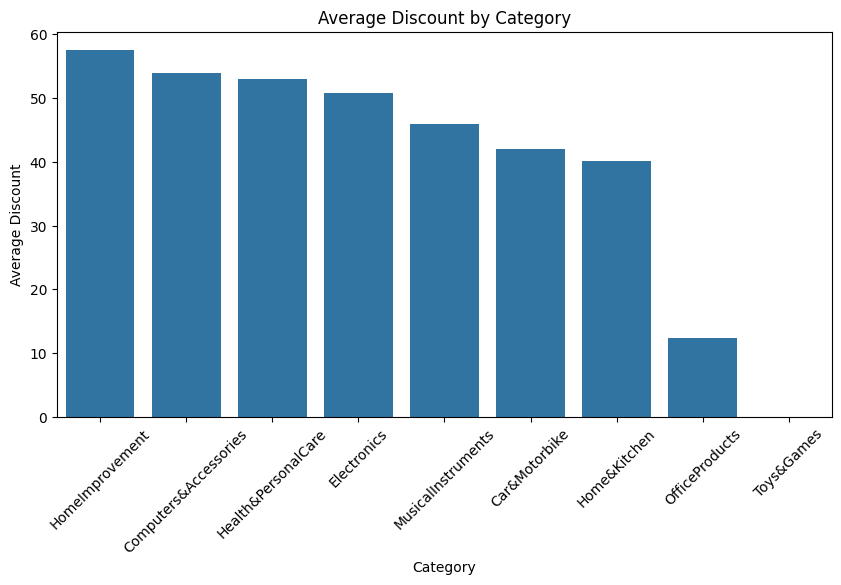

In [ ]:
avg_discount=df.groupby("main_category")["discount_percentage"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=avg_discount.index,y=avg_discount.values)
plt.xticks(rotation=45)
plt.xlabel("Category")
plt.ylabel("Average Discount")
plt.title("Average Discount by Category")
plt.show()

 6.Discount Percentage vs Rating

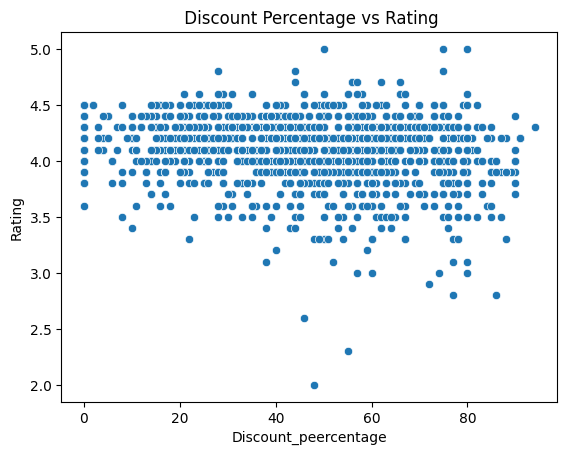

In [ ]:
sns.scatterplot(data=df,x="discount_percentage",y="rating")
plt.title(" Discount Percentage vs Rating")
plt.xlabel("Discount_peercentage")
plt.ylabel("Rating")
plt.show()

7 Correlation Heatmap

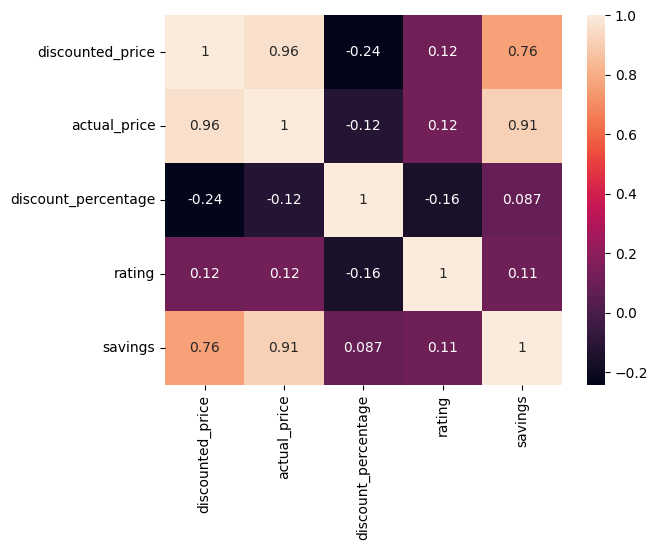

In [ ]:
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True
)
plt.show()

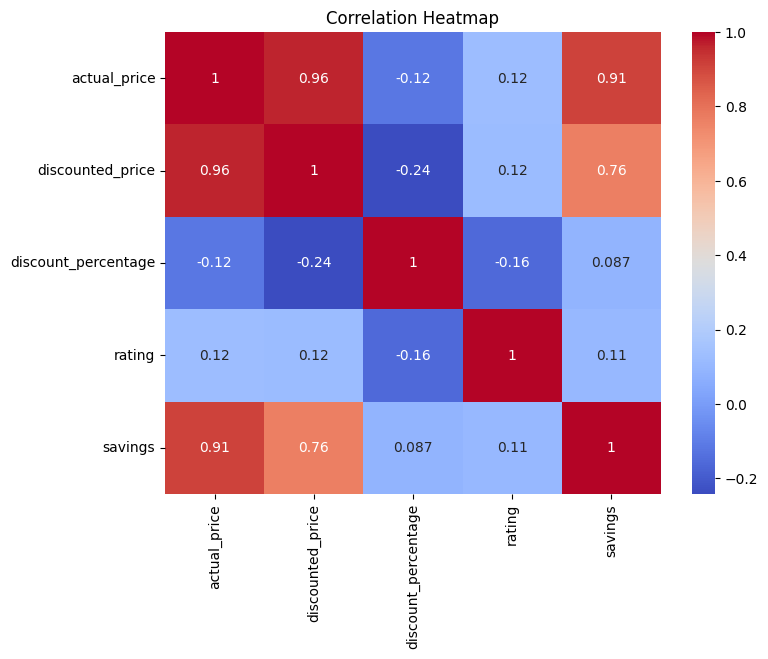

In [ ]:
numeric_cols = [
    'actual_price',
    'discounted_price',
    'discount_percentage',
    'rating',
    'savings'
]
plt.figure(figsize=(8,6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,user_id,main_category,savings
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...",Computers&Accessories,700.0
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,"AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...",Computers&Accessories,150.0
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...",Computers&Accessories,1700.0
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...",Computers&Accessories,370.0
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...",Computers&Accessories,245.0


1. Descriptive Statistics

In [ ]:
df[["actual_price","discounted_price","rating"]].describe()

,actual_price,discounted_price,rating
count,1465.000000,1465.000000,1464.000000
mean,5444.990635,3125.310874,4.096585
std,10874.826864,6944.304394,0.291674
min,39.000000,39.000000,2.000000
25%,800.000000,325.000000,4.000000
50%,1650.000000,799.000000,4.100000
75%,4295.000000,1999.000000,4.300000
max,139900.000000,77990.000000,5.000000


2. Skewness

In [ ]:
df["actual_price"].skew()
df["discounted_price"].skew()
df["rating"].skew()

np.float64(-1.2428954369559149)

3. Kurtosis

In [ ]:
df['actual_price'].kurt()

np.float64(29.723082279303387)

4. Correlation Analysis

In [ ]:
df[['actual_price','discounted_price',
    'discount_percentage',
    'rating',
    ]].corr()

,actual_price,discounted_price,discount_percentage,rating
actual_price,1.000000,0.961915,-0.118098,0.121642
discounted_price,0.961915,1.000000,-0.242412,0.120337
discount_percentage,-0.118098,-0.242412,1.000000,-0.155375
rating,0.121642,0.120337,-0.155375,1.000000


5. Category-wise Statistical Summary

In [ ]:
df.groupby('main_category')['rating'].agg(
    ['mean','median','std','min','max']
)

,mean,median,std,min,max
main_category,,,,,
Car&Motorbike,3.800000,3.80,NaN,3.8,3.8
Computers&Accessories,4.154967,4.20,0.261045,3.0,5.0
Electronics,4.081749,4.10,0.269620,2.8,4.7
Health&PersonalCare,4.000000,4.00,NaN,4.0,4.0
Home&Kitchen,4.040716,4.10,0.334687,2.0,4.8
HomeImprovement,4.250000,4.25,0.353553,4.0,4.5
MusicalInstruments,3.900000,3.90,0.141421,3.8,4.0
OfficeProducts,4.309677,4.30,0.149119,4.0,4.5
Toys&Games,4.300000,4.30,NaN,4.3,4.3


6.Hypothesis Testing

In [ ]:
from scipy.stats import pearsonr

pearsonr(
    df['discount_percentage'],
    df['rating']
)

PearsonRResult(statistic=np.float64(nan), pvalue=np.float64(nan))

7. Z-Score (Outlier Detection)

In [ ]:
from scipy.stats import zscore

df['price_zscore'] = zscore(df['actual_price'])
df[df['price_zscore'].abs() > 3]

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,user_id,main_category,savings,price_zscore
38,B0B3MMYHYW,OnePlus 126 cm (50 inches) Y Series 4K Ultra H...,"Electronics|HomeTheater,TV&Video|Televisions|S...",32999.0,45999.0,28,4.2,"AGDOVGWZKEQ3M6DA2GHV6WUZT5SA,AGEUXHN7U2Q26CM6T...",Electronics,13000.0,3.730437
61,B0B15CPR37,Samsung 108 cm (43 inches) Crystal 4K Neo Seri...,"Electronics|HomeTheater,TV&Video|Televisions|S...",32990.0,47900.0,31,4.3,"AHDIDVECFGA6OQRNUBPUO6366UGQ,AFSII6HTAHTHGXERU...",Electronics,14910.0,3.905304
72,B09RFC46VP,Redmi 108 cm (43 inches) 4K Ultra HD Android S...,"Electronics|HomeTheater,TV&Video|Televisions|S...",26999.0,42999.0,37,4.2,"AG6WSLLXZY52HSQUY5PRCXTCYQYQ,AHGJ2DNFP3OJWO73X...",Electronics,16000.0,3.454476
85,B09VCHLSJF,OnePlus 108 cm (43 inches) Y Series 4K Ultra H...,"Electronics|HomeTheater,TV&Video|Televisions|S...",29999.0,39999.0,25,4.2,"AGDOVGWZKEQ3M6DA2GHV6WUZT5SA,AGEUXHN7U2Q26CM6T...",Electronics,10000.0,3.178516
86,B0B1YZX72F,Acer 127 cm (50 inches) I Series 4K Ultra HD A...,"Electronics|HomeTheater,TV&Video|Televisions|S...",27999.0,40990.0,32,4.3,"AFSMISGEYDYIP3Z42UTQU4AKOYZQ,AF5ILQY4KFDTO5XHH...",Electronics,12991.0,3.269675
87,B092BJMT8Q,Samsung 108 cm (43 inches) Crystal 4K Series U...,"Electronics|HomeTheater,TV&Video|Televisions|S...",30990.0,52900.0,41,4.3,"AHDIDVECFGA6OQRNUBPUO6366UGQ,AFSII6HTAHTHGXERU...",Electronics,21910.0,4.365239
94,B09T3KB6JZ,TCL 100 cm (40 inches) Full HD Certified Andro...,"Electronics|HomeTheater,TV&Video|Televisions|S...",18990.0,40990.0,54,4.2,"AGACKHUULXIV2SLNKKA6GWQOP7JQ,AHX6DQRYIJWTTXZ22...",Electronics,22000.0,3.269675
108,B0B9XLX8VR,VU 139 cm (55 inches) The GloLED Series 4K Sma...,"Electronics|HomeTheater,TV&Video|Televisions|S...",37999.0,65000.0,42,4.3,"AHY6AK5LXBTGXDDXSU57ISMDW55Q,AGULFHMPCHCL32WCI...",Electronics,27001.0,5.478280
123,B099K9ZX65,Hisense 108 cm (43 inches) 4K Ultra HD Smart C...,"Electronics|HomeTheater,TV&Video|Televisions|S...",20990.0,44990.0,53,4.1,"AFP334GQV3WBH6XJIX5VITMYOH2A,AHAIKXSSOQ7R5GBPV...",Electronics,24000.0,3.637622
124,B08Y55LPBF,Redmi 126 cm (50 inches) 4K Ultra HD Android S...,"Electronics|HomeTheater,TV&Video|Televisions|S...",32999.0,44999.0,27,4.2,"AG6WSLLXZY52HSQUY5PRCXTCYQYQ,AHGJ2DNFP3OJWO73X...",Electronics,12000.0,3.638450


**Business Insights**


Electronics category has the highest number of products.

Most products have ratings above 4.0.

Actual price and discounted price are strongly correlated.

Higher discounts do not necessarily lead to higher ratings.

A few products account for a large share of customer ratings.

**Recommendations**

Focus promotions on highly rated products.

Increase visibility of top-performing categories.

Review low-rated categories for quality issues.

Highlight products with high ratings and high review counts.

**Conclusion**

This analysis examined Amazon products based on pricing, discounts, ratings, and customer engagement. Most products received positive ratings, with certain categories dominating the marketplace. Strong relationships were observed between actual and discounted prices, while discounts showed limited influence on ratings. The findings can help businesses optimize pricing strategies and improve customer satisfaction.